<a href="https://colab.research.google.com/github/tahminabintazaman-ux/CSE440-Project/blob/main/3_22201895_22301693_22201914.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
# ============================================================
# CSE440: NLP II - Final Project
# Multi-Class Text Classification using 20 Newsgroups
# ============================================================

# Install required libraries
!pip install -q transformers wordcloud gensim

# -----------------------------
# Standard Python libraries
# -----------------------------
import re
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# -----------------------------
# NLP libraries
# -----------------------------
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# -----------------------------
# PyTorch
# -----------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("CSE440 NLP II FINAL PROJECT")
print("=" * 60)
print(f"Random seed: {SEED}")
print(f"Active device: {device}")
print("=" * 60)

CSE440 NLP II FINAL PROJECT
Random seed: 42
Active device: cuda


# CSE440 NLP II Final Project

## Topic
Multi-Class Text Classification of Online Discussion Posts

## Problem Definition
The objective of this project is to automatically classify online discussion posts into one of 20 different newsgroup categories. This is a multi-class text classification problem in which each document belongs to one target category.

## Motivation
Large online discussion platforms contain huge volumes of user-generated text organized into different topics. Automatically categorizing these documents can help with information organization, topic discovery, search, moderation, and content management.

## Research Questions
1. How do different text representations, specifically GloVe and Word2Vec, affect classification performance?
2. How do traditional machine learning models compare with recurrent neural network architectures?
3. How does BERT Base compare with traditional ML and recurrent neural network models?
4. Which model and hyperparameter configuration provides the best performance?

In [54]:
# ============================================================
# 1. Dataset Collection
# ============================================================

from sklearn.datasets import fetch_20newsgroups

# Load both original train and test portions
# We combine them so that we can create our own
# reproducible train/validation/test split.

raw_train = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

raw_test = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

all_docs = list(raw_train.data) + list(raw_test.data)
all_labels = list(raw_train.target) + list(raw_test.target)

target_names = raw_train.target_names

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Total documents: {len(all_docs)}")
print(f"Number of classes: {len(target_names)}")
print(f"Language: English")
print("=" * 60)

print("\nClass names:")
for i, name in enumerate(target_names):
    print(f"{i}: {name}")

DATASET INFORMATION
Total documents: 18846
Number of classes: 20
Language: English

Class names:
0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc


In [55]:
# ============================================================
# 2. Text Cleaning
# ============================================================

def clean_text(text):

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove quote headers
    text = re.sub(
        r'In article.*?writes:?',
        ' ',
        text,
        flags=re.I
    )

    # Remove quoted lines
    text = re.sub(
        r'^\s*>.*$',
        ' ',
        text,
        flags=re.MULTILINE
    )

    # Remove metadata headers
    text = re.sub(
        r'^(Organization|Lines|NNTP-Posting-Host|Distribution|Reply-To|X-\S+):.*$',
        ' ',
        text,
        flags=re.MULTILINE
    )

    # Remove URLs
    text = re.sub(
        r'http\S+|www\.\S+',
        ' ',
        text
    )

    # Keep alphabetic characters only
    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    # Lowercase and normalize whitespace
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip().lower()

    return text


cleaned_docs = [clean_text(doc) for doc in all_docs]

# Remove documents with fewer than 5 words
paired = [
    (doc, label)
    for doc, label in zip(cleaned_docs, all_labels)
    if len(doc.split()) > 5
]

cleaned_docs, all_labels = map(list, zip(*paired))

df = pd.DataFrame({
    'text': cleaned_docs,
    'label': all_labels,
    'category': [target_names[label] for label in all_labels],
    'word_count': [len(doc.split()) for doc in cleaned_docs]
})

print(f"Documents after initial cleaning: {len(df)}")

display(df.head())

Documents after initial cleaning: 18049


,text,label,category,word_count
0,i was wondering if anyone out there could enli...,7,rec.autos,92
1,a fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware,89
2,well folks my mac plus finally gave up the gho...,4,comp.sys.mac.hardware,298
3,do you have weitek s address phone number i d ...,1,comp.graphics,18
4,from article by tom a baker my understanding i...,14,sci.space,70


In [56]:
# ============================================================
# 3. Dataset Quality Analysis
# ============================================================

print("=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

print(df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

duplicate_count = df.duplicated(subset=['text', 'label']).sum()

print(f"Duplicate documents: {duplicate_count}")

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

class_counts = df['category'].value_counts()

display(class_counts.to_frame("Number of Documents"))

print("\nMinimum class size:", class_counts.min())
print("Maximum class size:", class_counts.max())
print("Imbalance ratio:", round(class_counts.max() / class_counts.min(), 2))

MISSING VALUE CHECK
text          0
label         0
category      0
word_count    0
dtype: int64

DUPLICATE CHECK
Duplicate documents: 67

CLASS DISTRIBUTION


,Number of Documents
category,
soc.religion.christian,970
comp.windows.x,961
comp.sys.ibm.pc.hardware,959
rec.sport.hockey,957
sci.med,952
sci.space,947
rec.motorcycles,946
sci.electronics,945
comp.graphics,942



Minimum class size: 597
Maximum class size: 970
Imbalance ratio: 1.62


In [57]:
# Remove exact duplicate text-label pairs if present
before = len(df)

df = df.drop_duplicates(
    subset=['text', 'label']
).reset_index(drop=True)

after = len(df)

print(f"\nRemoved duplicates: {before - after}")
print(f"Remaining documents: {after}")


Removed duplicates: 67
Remaining documents: 17982


In [58]:
# ============================================================
# 4. Dataset Statistics
# ============================================================

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"Total samples: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print(f"Average words/document: {df['word_count'].mean():.2f}")
print(f"Median words/document: {df['word_count'].median():.2f}")
print(f"Minimum words/document: {df['word_count'].min()}")
print(f"Maximum words/document: {df['word_count'].max()}")

print("\nClass distribution:")
display(df['category'].value_counts())

DATASET STATISTICS
Total samples: 17982
Number of classes: 20
Average words/document: 194.78
Median words/document: 86.00
Minimum words/document: 6
Maximum words/document: 20035

Class distribution:


,count
category,
soc.religion.christian,968
comp.sys.ibm.pc.hardware,957
rec.sport.hockey,957
sci.med,949
comp.windows.x,945
rec.motorcycles,944
sci.electronics,943
sci.space,942
comp.graphics,938


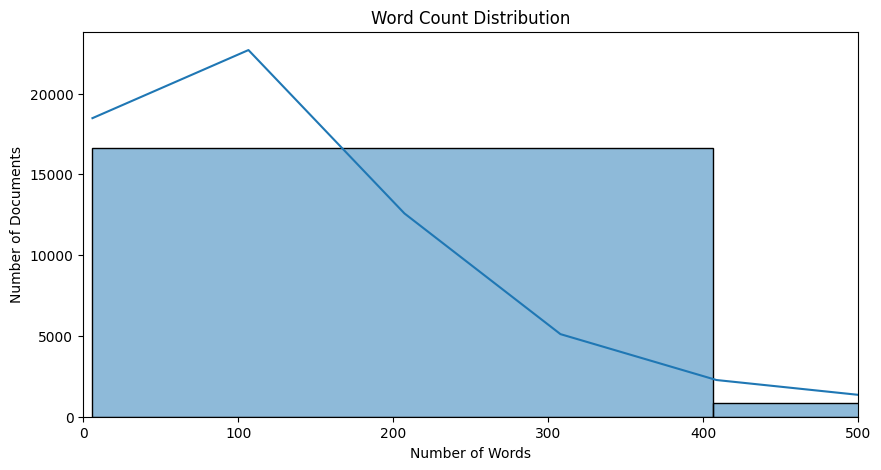

In [59]:
# ============================================================
# 5. Exploratory Data Analysis
# ============================================================

from wordcloud import WordCloud

# -----------------------------
# Word count distribution
# -----------------------------
plt.figure(figsize=(10, 5))

sns.histplot(
    df['word_count'],
    bins=50,
    kde=True
)

plt.xlim(0, 500)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.show()

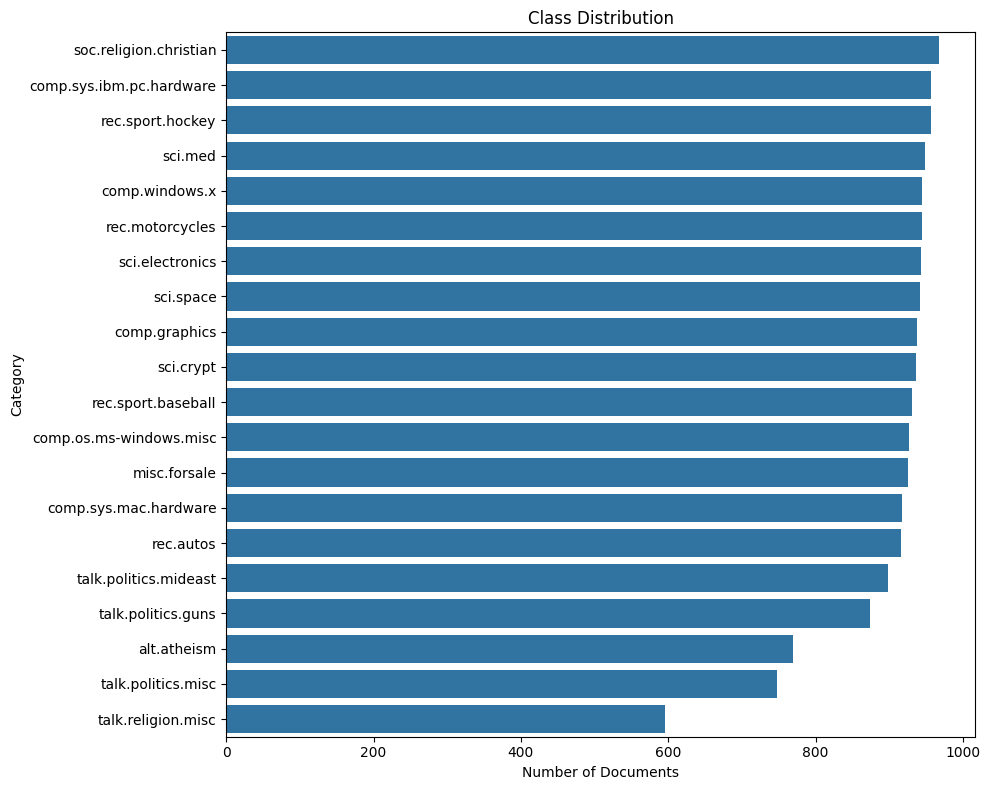

In [60]:
# -----------------------------
# Class distribution
# -----------------------------

plt.figure(figsize=(10, 8))

sns.countplot(
    y=df['category'],
    order=df['category'].value_counts().index
)

plt.title("Class Distribution")
plt.xlabel("Number of Documents")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

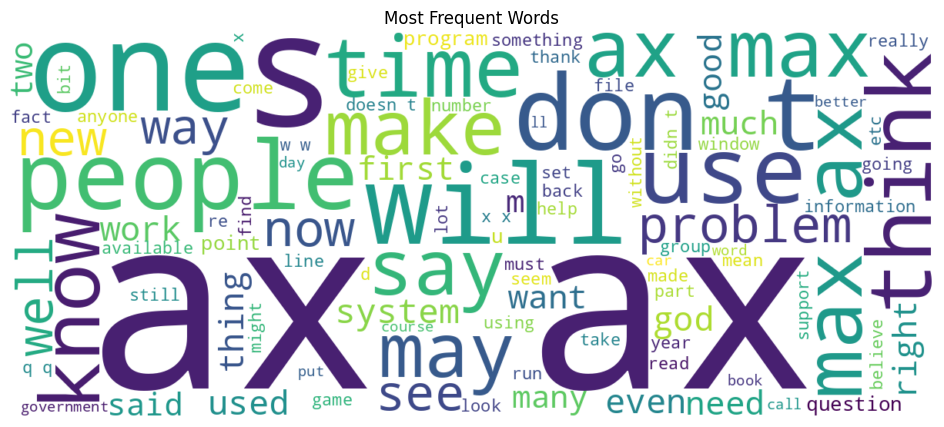

In [61]:
# -----------------------------
# Word cloud
# -----------------------------

all_text = " ".join(df['text'])

wordcloud = WordCloud(
    width=1200,
    height=500,
    max_words=100,
    random_state=42,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words")
plt.show()

## Text Preprocessing

The cleaned documents are further processed by removing English stopwords and applying lemmatization. Stopword removal reduces common words that generally provide limited information for topic classification. Lemmatization converts words into their base forms, helping reduce vocabulary variation. Tokens with fewer than three characters are removed. Documents containing very few remaining words are excluded because they provide limited information for classification.

In [62]:
# ============================================================
# 6. Text Preprocessing
# ============================================================

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def lemmatize_and_remove_stopwords(text):

    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    return ' '.join(tokens)

# Save basic-cleaned text for Bonus 2 ablation study
df['basic_text'] = df['text'].copy()

df['text'] = df['text'].apply(
    lemmatize_and_remove_stopwords
)

df['word_count'] = (
    df['text']
    .str.split()
    .apply(len)
)

# Remove extremely short documents
before = len(df)

df = df[
    df['word_count'] > 3
].reset_index(drop=True)

print(f"Documents removed after preprocessing: {before - len(df)}")
print(f"Final dataset size: {len(df)}")

display(df.head())

Documents removed after preprocessing: 119
Final dataset size: 17863


,text,label,category,word_count,basic_text
0,wondering anyone could enlighten car saw day d...,7,rec.autos,43,i was wondering if anyone out there could enli...
1,fair number brave soul upgraded clock oscillat...,4,comp.sys.mac.hardware,53,a fair number of brave souls who upgraded thei...
2,well folk mac plus finally gave ghost weekend ...,4,comp.sys.mac.hardware,140,well folks my mac plus finally gave up the gho...
3,weitek address phone number like get informati...,1,comp.graphics,8,do you have weitek s address phone number i d ...
4,article tom baker understanding expected error...,14,sci.space,34,from article by tom a baker my understanding i...


In [63]:
# ============================================================
# 7. Post-Preprocessing Analysis
# ============================================================

print("Missing values after preprocessing:")
print(df.isnull().sum())

print("\nDuplicate documents after preprocessing:")
print(df.duplicated(subset=['text', 'label']).sum())

print("\nFinal class distribution:")
display(df['category'].value_counts())

print("\nFinal word-count statistics:")
print(df['word_count'].describe())

Missing values after preprocessing:
text          0
label         0
category      0
word_count    0
basic_text    0
dtype: int64

Duplicate documents after preprocessing:
5

Final class distribution:


,count
category,
soc.religion.christian,968
comp.sys.ibm.pc.hardware,951
rec.sport.hockey,949
sci.med,945
comp.windows.x,942
sci.space,938
sci.electronics,935
sci.crypt,933
comp.graphics,932



Final word-count statistics:
count    17863.000000
mean        95.488496
std        268.898869
min          4.000000
25%         22.000000
50%         43.000000
75%         84.000000
max       6324.000000
Name: word_count, dtype: float64


In [64]:
# ============================================================
# 8. Train / Validation / Test Split
# ============================================================

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)

print(
    f"Train: {len(train_df):,} "
    f"({len(train_df)/len(df):.1%})"
)

print(
    f"Validation: {len(val_df):,} "
    f"({len(val_df)/len(df):.1%})"
)

print(
    f"Test: {len(test_df):,} "
    f"({len(test_df)/len(df):.1%})"
)

print("\nClass distribution in each split:")

print("\nTRAIN")
display(train_df['category'].value_counts())

print("\nVALIDATION")
display(val_df['category'].value_counts())

print("\nTEST")
display(test_df['category'].value_counts())

DATA SPLIT
Train: 12,504 (70.0%)
Validation: 2,679 (15.0%)
Test: 2,680 (15.0%)

Class distribution in each split:

TRAIN


,count
category,
soc.religion.christian,678
comp.sys.ibm.pc.hardware,666
rec.sport.hockey,664
sci.med,661
comp.windows.x,659
sci.space,657
sci.electronics,655
sci.crypt,653
rec.motorcycles,652



VALIDATION


,count
category,
soc.religion.christian,145
rec.sport.hockey,142
sci.med,142
comp.sys.ibm.pc.hardware,142
comp.windows.x,141
sci.space,140
sci.crypt,140
comp.graphics,140
sci.electronics,140



TEST


,count
category,
soc.religion.christian,145
rec.sport.hockey,143
comp.sys.ibm.pc.hardware,143
sci.med,142
comp.windows.x,142
sci.space,141
comp.graphics,140
rec.motorcycles,140
sci.crypt,140


In [65]:
!pip install -q gensim

In [66]:
import gensim.downloader as gensim_api
from gensim.models import Word2Vec

# ------------------------------------------------------------------
# Embedding Setup: GloVe (pretrained) + Word2Vec (trained on corpus)
# ------------------------------------------------------------------
EMBED_DIM = 100

# --- GloVe: load pretrained embeddings (Wikipedia + Gigaword, 100d) ---
print("Loading pretrained GloVe vectors (glove-wiki-gigaword-100)...")
glove_vectors = gensim_api.load('glove-wiki-gigaword-100')
print(f"GloVe vocabulary size: {len(glove_vectors)}")

# --- Word2Vec: trained strictly on the training set tokens ---
train_tokens = [text.split() for text in train_df['text']]
val_tokens   = [text.split() for text in val_df['text']]
test_tokens  = [text.split() for text in test_df['text']]

model_w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBED_DIM,
    window=5,
    min_count=3,
    workers=4,
    seed=42
)
print(f"Word2Vec vocabulary size: {len(model_w2v.wv)}")

# --- Shared helper: average word vectors into one document vector ---
def doc_to_vector(tokens, keyed_vectors, vector_size=EMBED_DIM):
    vectors = [keyed_vectors[t] for t in tokens if t in keyed_vectors]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

def build_doc_matrix(token_lists, keyed_vectors, vector_size=EMBED_DIM):
    return np.array([doc_to_vector(t, keyed_vectors, vector_size) for t in token_lists])

# GloVe document matrices
X_train_glove = build_doc_matrix(train_tokens, glove_vectors)
X_val_glove   = build_doc_matrix(val_tokens, glove_vectors)
X_test_glove  = build_doc_matrix(test_tokens, glove_vectors)

# Word2Vec document matrices
X_train_w2v = build_doc_matrix(train_tokens, model_w2v.wv)
X_val_w2v   = build_doc_matrix(val_tokens, model_w2v.wv)
X_test_w2v  = build_doc_matrix(test_tokens, model_w2v.wv)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# Bundle both embedding types so the rest of the notebook can loop over them
embedding_sets = {
    'GloVe':    {'train': X_train_glove, 'val': X_val_glove, 'test': X_test_glove},
    'Word2Vec': {'train': X_train_w2v,   'val': X_val_w2v,   'test': X_test_w2v},
}

print(f"GloVe shapes    -> train: {X_train_glove.shape}, val: {X_val_glove.shape}, test: {X_test_glove.shape}")
print(f"Word2Vec shapes -> train: {X_train_w2v.shape}, val: {X_val_w2v.shape}, test: {X_test_w2v.shape}")


Loading pretrained GloVe vectors (glove-wiki-gigaword-100)...
GloVe vocabulary size: 400000
Word2Vec vocabulary size: 25552
GloVe shapes    -> train: (12504, 100), val: (2679, 100), test: (2680, 100)
Word2Vec shapes -> train: (12504, 100), val: (2679, 100), test: (2680, 100)


In [67]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Master log table tracking hyperparameter tuning runs
tuning_records = []

# Fit traditional ML model and log validation set performance
def eval_ml_config(model_name, config_id, embedding_name, model, X_tr, X_v, y_tr, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    acc = accuracy_score(y_v, preds)
    f1 = f1_score(y_v, preds, average='macro')

    tuning_records.append({
        'Family': 'Traditional ML',
        'Model Name': model_name,
        'Embedding': embedding_name,
        'Config ID': config_id,
        'Hyperparameters': str(model.get_params()),
        'Val Accuracy': round(acc, 4),
        'Val Macro F1': round(f1, 4),
        'Model Object': model
    })
    print(f"[{model_name} | {embedding_name} | {config_id}] -> Val Acc: {acc:.4f} | Val F1: {f1:.4f}")


In [68]:
# Naive Bayes (Gaussian) across both embeddings
# Dense embeddings contain negative values, so Gaussian rather than Multinomial NB is used
nb_var_smoothing = [1e-9, 1e-8, 1e-7]
for embedding_name, data in embedding_sets.items():
    for idx, vs in enumerate(nb_var_smoothing, 1):
        eval_ml_config('Naive Bayes', f'Config_{idx}', embedding_name,
                        GaussianNB(var_smoothing=vs), data['train'], data['val'], y_train, y_val)


[Naive Bayes | GloVe | Config_1] -> Val Acc: 0.4860 | Val F1: 0.4715
[Naive Bayes | GloVe | Config_2] -> Val Acc: 0.4860 | Val F1: 0.4715
[Naive Bayes | GloVe | Config_3] -> Val Acc: 0.4860 | Val F1: 0.4715
[Naive Bayes | Word2Vec | Config_1] -> Val Acc: 0.4072 | Val F1: 0.3943
[Naive Bayes | Word2Vec | Config_2] -> Val Acc: 0.4072 | Val F1: 0.3943
[Naive Bayes | Word2Vec | Config_3] -> Val Acc: 0.4072 | Val F1: 0.3943


In [69]:
# Logistic Regression across both embeddings
lr_c_values = [0.1, 1.0, 10.0]
for embedding_name, data in embedding_sets.items():
    for idx, c in enumerate(lr_c_values, 1):
        eval_ml_config('Logistic Regression', f'Config_{idx}', embedding_name,
                        LogisticRegression(C=c, max_iter=500, random_state=42),
                        data['train'], data['val'], y_train, y_val)


[Logistic Regression | GloVe | Config_1] -> Val Acc: 0.5991 | Val F1: 0.5757
[Logistic Regression | GloVe | Config_2] -> Val Acc: 0.6069 | Val F1: 0.5888
[Logistic Regression | GloVe | Config_3] -> Val Acc: 0.6036 | Val F1: 0.5857
[Logistic Regression | Word2Vec | Config_1] -> Val Acc: 0.5095 | Val F1: 0.4821
[Logistic Regression | Word2Vec | Config_2] -> Val Acc: 0.5375 | Val F1: 0.5143
[Logistic Regression | Word2Vec | Config_3] -> Val Acc: 0.5651 | Val F1: 0.5459


In [70]:
# Random Forest across both embeddings
rf_params = [{'n_estimators': 100, 'max_depth': 20}, {'n_estimators': 200, 'max_depth': 50}, {'n_estimators': 300, 'max_depth': None}]
for embedding_name, data in embedding_sets.items():
    for idx, params in enumerate(rf_params, 1):
        eval_ml_config('Random Forest', f'Config_{idx}', embedding_name,
                        RandomForestClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42, n_jobs=-1),
                        data['train'], data['val'], y_train, y_val)


[Random Forest | GloVe | Config_1] -> Val Acc: 0.5629 | Val F1: 0.5421
[Random Forest | GloVe | Config_2] -> Val Acc: 0.5711 | Val F1: 0.5503
[Random Forest | GloVe | Config_3] -> Val Acc: 0.5782 | Val F1: 0.5565
[Random Forest | Word2Vec | Config_1] -> Val Acc: 0.5013 | Val F1: 0.4857
[Random Forest | Word2Vec | Config_2] -> Val Acc: 0.5009 | Val F1: 0.4842
[Random Forest | Word2Vec | Config_3] -> Val Acc: 0.5032 | Val F1: 0.4858


In [71]:
# Construct Vocabulary mapping from training tokens
all_train_words = [word for doc in train_df['text'] for word in doc.split()]
vocab_counts = Counter(all_train_words)

# Filter words first so indices remain contiguous without gaps
filtered_words = [word for word, count in vocab_counts.items() if count >= 3]

# Create contiguous index mapping (starting at 2)
vocab = {word: idx + 2 for idx, word in enumerate(filtered_words)}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

VOCAB_SIZE = len(vocab)
MAX_LEN = 120

# Encode text into fixed length token ID sequences
def encode_text(text, vocab_map, max_length=MAX_LEN):
    tokens = text.split()
    ids = [vocab_map.get(t, 1) for t in tokens[:max_length]]
    if len(ids) < max_length:
        ids += [0] * (max_length - len(ids))
    return ids

# Custom PyTorch Dataset for Recurrent Models
class SequenceDataset(Dataset):
    def __init__(self, texts, labels, vocab_map):
        self.encoded = [encode_text(t, vocab_map) for t in texts]
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.encoded[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

# Instantiate PyTorch DataLoaders
train_ds_seq = SequenceDataset(train_df['text'], y_train, vocab)
val_ds_seq   = SequenceDataset(val_df['text'], y_val, vocab)
test_ds_seq  = SequenceDataset(test_df['text'], y_test, vocab)

train_loader_rnn = DataLoader(train_ds_seq, batch_size=64, shuffle=True)
val_loader_rnn   = DataLoader(val_ds_seq, batch_size=128, shuffle=False)
test_loader_rnn  = DataLoader(test_ds_seq, batch_size=128, shuffle=False)

# Build an embedding weight matrix aligned with `vocab` from any KeyedVectors source
# (works for both the pretrained GloVe vectors and the custom-trained Word2Vec vectors)
def build_embedding_matrix(vocab_map, keyed_vectors, vector_size=EMBED_DIM):
    matrix = np.zeros((len(vocab_map), vector_size))
    for word, idx in vocab_map.items():
        if word in keyed_vectors:
            matrix[idx] = keyed_vectors[word]
        else:
            matrix[idx] = np.random.normal(scale=0.5, size=(vector_size,))
    return torch.tensor(matrix, dtype=torch.float32)

# One pretrained weight tensor per embedding type, so the RNN cell can loop over both
pretrained_weights = {
    'GloVe':    build_embedding_matrix(vocab, glove_vectors),
    'Word2Vec': build_embedding_matrix(vocab, model_w2v.wv),
}


In [72]:
# Unified PyTorch architecture supporting SimpleRNN, GRU, LSTM, and bidirectional variants
class UnifiedRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, cell_type='lstm', bidirectional=False, dropout=0.3, weights=None):
        super(UnifiedRNNClassifier, self).__init__()

        if weights is not None:
            self.embedding = nn.Embedding.from_pretrained(weights, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.cell_type = cell_type.lower()
        self.bidirectional = bidirectional

        kwargs = {
            'input_size': embed_dim,
            'hidden_size': hidden_dim,
            'num_layers': 1,
            'batch_first': True,
            'bidirectional': bidirectional
        }

        if self.cell_type == 'simplernn':
            self.rnn = nn.RNN(**kwargs)
        elif self.cell_type == 'gru':
            self.rnn = nn.GRU(**kwargs)
        elif self.cell_type == 'lstm':
            self.rnn = nn.LSTM(**kwargs)

        directions = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * directions, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        if self.cell_type == 'lstm':
            out, (hn, cn) = self.rnn(embedded)
        else:
            out, hn = self.rnn(embedded)

        if self.bidirectional:
            cat_hn = torch.cat((hn[-2], hn[-1]), dim=1)
            logits = self.fc(self.dropout(cat_hn))
        else:
            logits = self.fc(self.dropout(hn[-1]))

        return logits

# Recurrent model training execution function (shared by every architecture cell below)
def train_rnn_model(model_name, config_id, embedding_name, weights, cell_type, bi_flag, hidden_dim, lr, dropout, epochs=6):
    model = UnifiedRNNClassifier(VOCAB_SIZE, EMBED_DIM, hidden_dim, 20, cell_type, bi_flag, dropout, weights).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for x_b, y_b in train_loader_rnn:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(x_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

    # Evaluate model on validation set
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_b, y_b in val_loader_rnn:
            x_b = x_b.to(device)
            logits = model(x_b)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_b.numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    tuning_records.append({
        'Family': 'Recurrent NN',
        'Model Name': model_name,
        'Embedding': embedding_name,
        'Config ID': config_id,
        'Hyperparameters': f"hidden={hidden_dim}, lr={lr}, drop={dropout}",
        'Val Accuracy': round(acc, 4),
        'Val Macro F1': round(f1, 4),
        'Model Object': model
    })
    print(f"[{model_name} | {embedding_name} | {config_id}] -> Val Acc: {acc:.4f} | Val F1: {f1:.4f}")

# 3 Hyperparameter Configurations, shared across every recurrent architecture below
rnn_configs = [
    {'hidden_dim': 64, 'lr': 0.001, 'dropout': 0.2},
    {'hidden_dim': 128, 'lr': 0.0008, 'dropout': 0.3},
    {'hidden_dim': 256, 'lr': 0.0005, 'dropout': 0.4}
]


In [73]:
# SimpleRNN across both embeddings
for embedding_name, weights in pretrained_weights.items():
    for idx, cfg in enumerate(rnn_configs, 1):
        train_rnn_model('SimpleRNN', f'Config_{idx}', embedding_name, weights, 'simplernn', False,
                         cfg['hidden_dim'], cfg['lr'], cfg['dropout'])


[SimpleRNN | GloVe | Config_1] -> Val Acc: 0.0859 | Val F1: 0.0569
[SimpleRNN | GloVe | Config_2] -> Val Acc: 0.0847 | Val F1: 0.0543
[SimpleRNN | GloVe | Config_3] -> Val Acc: 0.0806 | Val F1: 0.0422
[SimpleRNN | Word2Vec | Config_1] -> Val Acc: 0.1194 | Val F1: 0.0572
[SimpleRNN | Word2Vec | Config_2] -> Val Acc: 0.1004 | Val F1: 0.0674
[SimpleRNN | Word2Vec | Config_3] -> Val Acc: 0.1198 | Val F1: 0.0664


In [74]:
# GRU across both embeddings
for embedding_name, weights in pretrained_weights.items():
    for idx, cfg in enumerate(rnn_configs, 1):
        train_rnn_model('GRU', f'Config_{idx}', embedding_name, weights, 'gru', False,
                         cfg['hidden_dim'], cfg['lr'], cfg['dropout'])


[GRU | GloVe | Config_1] -> Val Acc: 0.5666 | Val F1: 0.5414
[GRU | GloVe | Config_2] -> Val Acc: 0.4867 | Val F1: 0.4528
[GRU | GloVe | Config_3] -> Val Acc: 0.3662 | Val F1: 0.3088
[GRU | Word2Vec | Config_1] -> Val Acc: 0.5704 | Val F1: 0.5411
[GRU | Word2Vec | Config_2] -> Val Acc: 0.3598 | Val F1: 0.3148
[GRU | Word2Vec | Config_3] -> Val Acc: 0.4155 | Val F1: 0.3664


In [75]:
# LSTM across both embeddings
for embedding_name, weights in pretrained_weights.items():
    for idx, cfg in enumerate(rnn_configs, 1):
        train_rnn_model('LSTM', f'Config_{idx}', embedding_name, weights, 'lstm', False,
                         cfg['hidden_dim'], cfg['lr'], cfg['dropout'])


[LSTM | GloVe | Config_1] -> Val Acc: 0.2090 | Val F1: 0.1229
[LSTM | GloVe | Config_2] -> Val Acc: 0.1109 | Val F1: 0.0488
[LSTM | GloVe | Config_3] -> Val Acc: 0.1258 | Val F1: 0.0601
[LSTM | Word2Vec | Config_1] -> Val Acc: 0.3038 | Val F1: 0.2412
[LSTM | Word2Vec | Config_2] -> Val Acc: 0.2758 | Val F1: 0.2079
[LSTM | Word2Vec | Config_3] -> Val Acc: 0.2225 | Val F1: 0.1617


In [76]:
# Bidirectional SimpleRNN across both embeddings
for embedding_name, weights in pretrained_weights.items():
    for idx, cfg in enumerate(rnn_configs, 1):
        train_rnn_model('Bidirectional SimpleRNN', f'Config_{idx}', embedding_name, weights, 'simplernn', True,
                         cfg['hidden_dim'], cfg['lr'], cfg['dropout'])


[Bidirectional SimpleRNN | GloVe | Config_1] -> Val Acc: 0.3733 | Val F1: 0.3439
[Bidirectional SimpleRNN | GloVe | Config_2] -> Val Acc: 0.3606 | Val F1: 0.3233
[Bidirectional SimpleRNN | GloVe | Config_3] -> Val Acc: 0.2856 | Val F1: 0.2559
[Bidirectional SimpleRNN | Word2Vec | Config_1] -> Val Acc: 0.3927 | Val F1: 0.3647
[Bidirectional SimpleRNN | Word2Vec | Config_2] -> Val Acc: 0.2691 | Val F1: 0.2382
[Bidirectional SimpleRNN | Word2Vec | Config_3] -> Val Acc: 0.3654 | Val F1: 0.3199


In [77]:
# Bidirectional GRU across both embeddings
for embedding_name, weights in pretrained_weights.items():
    for idx, cfg in enumerate(rnn_configs, 1):
        train_rnn_model('Bidirectional GRU', f'Config_{idx}', embedding_name, weights, 'gru', True,
                         cfg['hidden_dim'], cfg['lr'], cfg['dropout'])


[Bidirectional GRU | GloVe | Config_1] -> Val Acc: 0.6794 | Val F1: 0.6573
[Bidirectional GRU | GloVe | Config_2] -> Val Acc: 0.6782 | Val F1: 0.6584
[Bidirectional GRU | GloVe | Config_3] -> Val Acc: 0.6424 | Val F1: 0.6176
[Bidirectional GRU | Word2Vec | Config_1] -> Val Acc: 0.6614 | Val F1: 0.6518
[Bidirectional GRU | Word2Vec | Config_2] -> Val Acc: 0.6405 | Val F1: 0.6177
[Bidirectional GRU | Word2Vec | Config_3] -> Val Acc: 0.5677 | Val F1: 0.5422


In [78]:
# Bidirectional LSTM across both embeddings
for embedding_name, weights in pretrained_weights.items():
    for idx, cfg in enumerate(rnn_configs, 1):
        train_rnn_model('Bidirectional LSTM', f'Config_{idx}', embedding_name, weights, 'lstm', True,
                         cfg['hidden_dim'], cfg['lr'], cfg['dropout'])


[Bidirectional LSTM | GloVe | Config_1] -> Val Acc: 0.6495 | Val F1: 0.6247
[Bidirectional LSTM | GloVe | Config_2] -> Val Acc: 0.5640 | Val F1: 0.5280
[Bidirectional LSTM | GloVe | Config_3] -> Val Acc: 0.5543 | Val F1: 0.5272
[Bidirectional LSTM | Word2Vec | Config_1] -> Val Acc: 0.6054 | Val F1: 0.5821
[Bidirectional LSTM | Word2Vec | Config_2] -> Val Acc: 0.5857 | Val F1: 0.5566
[Bidirectional LSTM | Word2Vec | Config_3] -> Val Acc: 0.5136 | Val F1: 0.4854


In [79]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import gc

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')

# Custom PyTorch Dataset for BERT subword tokenization
class BERTDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer_bert(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds_bert = BERTDataset(train_df['text'], y_train)
val_ds_bert   = BERTDataset(val_df['text'], y_val)
test_ds_bert  = BERTDataset(test_df['text'], y_test)

val_loader_bert  = DataLoader(val_ds_bert, batch_size=32)
test_loader_bert = DataLoader(test_ds_bert, batch_size=32)

# BERT fine-tuning execution function
def train_bert_config(config_id, lr, batch_size, epochs=1):
    # Clear PyTorch GPU memory before every run
    gc.collect()
    torch.cuda.empty_cache()

    train_loader_b = DataLoader(train_ds_bert, batch_size=batch_size, shuffle=True)
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=20).to(device)
    optimizer = AdamW(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        for batch in train_loader_b:
            optimizer.zero_grad()
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(ids, attention_mask=mask, labels=labels)
            outputs.loss.backward()
            optimizer.step()

    # Evaluate model on validation set
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in val_loader_bert:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            logits = model(ids, attention_mask=mask).logits
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch['label'].numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    tuning_records.append({
        'Family': 'Transformer',
        'Model Name': 'BERT Base Uncased',
        'Embedding': 'N/A',
        'Config ID': config_id,
        'Hyperparameters': f"lr={lr}, batch={batch_size}, epochs={epochs}",
        'Val Accuracy': round(acc, 4),
        'Val Macro F1': round(f1, 4),
        'Model Object': model
    })
    print(f"✅ [BERT Base | {config_id}] -> Val Acc: {acc:.4f} | Val F1: {f1:.4f}")

# Train 3 BERT Configurations (1 epoch per config for speed and stability)
train_bert_config('Config_1', lr=2e-5, batch_size=32, epochs=1)
train_bert_config('Config_2', lr=3e-5, batch_size=32, epochs=1)
train_bert_config('Config_3', lr=5e-5, batch_size=32, epochs=1)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ [BERT Base | Config_1] -> Val Acc: 0.6920 | Val F1: 0.6678


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ [BERT Base | Config_2] -> Val Acc: 0.7032 | Val F1: 0.6804


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ [BERT Base | Config_3] -> Val Acc: 0.7115 | Val F1: 0.6874


In [80]:
# ============================================================
# FINAL EXPERIMENT SUMMARY
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

df_results = pd.DataFrame(tuning_records)

print("=" * 80)
print("COMPLETE HYPERPARAMETER TUNING RESULTS")
print("=" * 80)

print(f"Total tuning runs: {len(df_results)}")

display(
    df_results[
        [
            'Family',
            'Model Name',
            'Embedding',
            'Config ID',
            'Hyperparameters',
            'Val Accuracy',
            'Val Macro F1'
        ]
    ]
)

COMPLETE HYPERPARAMETER TUNING RESULTS
Total tuning runs: 57


,Family,Model Name,Embedding,Config ID,Hyperparameters,Val Accuracy,Val Macro F1
0,Traditional ML,Naive Bayes,GloVe,Config_1,"{'priors': None, 'var_smoothing': 1e-09}",0.4860,0.4715
1,Traditional ML,Naive Bayes,GloVe,Config_2,"{'priors': None, 'var_smoothing': 1e-08}",0.4860,0.4715
2,Traditional ML,Naive Bayes,GloVe,Config_3,"{'priors': None, 'var_smoothing': 1e-07}",0.4860,0.4715
3,Traditional ML,Naive Bayes,Word2Vec,Config_1,"{'priors': None, 'var_smoothing': 1e-09}",0.4072,0.3943
4,Traditional ML,Naive Bayes,Word2Vec,Config_2,"{'priors': None, 'var_smoothing': 1e-08}",0.4072,0.3943
5,Traditional ML,Naive Bayes,Word2Vec,Config_3,"{'priors': None, 'var_smoothing': 1e-07}",0.4072,0.3943
6,Traditional ML,Logistic Regression,GloVe,Config_1,"{'C': 0.1, 'class_weight': None, 'dual': False...",0.5991,0.5757
7,Traditional ML,Logistic Regression,GloVe,Config_2,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.6069,0.5888
8,Traditional ML,Logistic Regression,GloVe,Config_3,"{'C': 10.0, 'class_weight': None, 'dual': Fals...",0.6036,0.5857
9,Traditional ML,Logistic Regression,Word2Vec,Config_1,"{'C': 0.1, 'class_weight': None, 'dual': False...",0.5095,0.4821


In [81]:
# ============================================================
# BEST CONFIGURATION FOR EVERY MODEL
# ============================================================

best_configs = (
    df_results
    .sort_values('Val Macro F1', ascending=False)
    .groupby('Model Name', as_index=False)
    .first()
)

print("=" * 80)
print("BEST CONFIGURATION FOR EACH MODEL")
print("=" * 80)

display(
    best_configs[
        [
            'Family',
            'Model Name',
            'Embedding',
            'Config ID',
            'Hyperparameters',
            'Val Accuracy',
            'Val Macro F1'
        ]
    ].sort_values(
        'Val Macro F1',
        ascending=False
    )
)

BEST CONFIGURATION FOR EACH MODEL


,Family,Model Name,Embedding,Config ID,Hyperparameters,Val Accuracy,Val Macro F1
0,Transformer,BERT Base Uncased,N/A,Config_3,"lr=5e-05, batch=32, epochs=1",0.7115,0.6874
1,Recurrent NN,Bidirectional GRU,GloVe,Config_2,"hidden=128, lr=0.0008, drop=0.3",0.6782,0.6584
2,Recurrent NN,Bidirectional LSTM,GloVe,Config_1,"hidden=64, lr=0.001, drop=0.2",0.6495,0.6247
6,Traditional ML,Logistic Regression,GloVe,Config_2,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.6069,0.5888
8,Traditional ML,Random Forest,GloVe,Config_3,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.5782,0.5565
4,Recurrent NN,GRU,GloVe,Config_1,"hidden=64, lr=0.001, drop=0.2",0.5666,0.5414
7,Traditional ML,Naive Bayes,GloVe,Config_1,"{'priors': None, 'var_smoothing': 1e-09}",0.4860,0.4715
3,Recurrent NN,Bidirectional SimpleRNN,Word2Vec,Config_1,"hidden=64, lr=0.001, drop=0.2",0.3927,0.3647
5,Recurrent NN,LSTM,Word2Vec,Config_1,"hidden=64, lr=0.001, drop=0.2",0.3038,0.2412
9,Recurrent NN,SimpleRNN,Word2Vec,Config_2,"hidden=128, lr=0.0008, drop=0.3",0.1004,0.0674


In [82]:
# ============================================================
# FINAL TEST SET EVALUATION FOR EVERY MODEL
# ============================================================

test_results = []
test_predictions = {}

for _, row in best_configs.iterrows():

    model_name = row['Model Name']
    family = row['Family']
    embedding_name = row['Embedding']
    model = row['Model Object']

    print("\n" + "=" * 80)
    print(f"Evaluating: {model_name}")
    print(f"Embedding: {embedding_name}")
    print(f"Configuration: {row['Config ID']}")
    print("=" * 80)

    # --------------------------------------------------------
    # Traditional ML
    # --------------------------------------------------------
    if family == 'Traditional ML':

        X_test = embedding_sets[
            embedding_name
        ]['test']

        predictions = model.predict(X_test)

    # --------------------------------------------------------
    # Recurrent Neural Network
    # --------------------------------------------------------
    elif family == 'Recurrent NN':

        model.eval()

        predictions = []

        with torch.no_grad():

            for x_batch, _ in test_loader_rnn:

                x_batch = x_batch.to(device)

                logits = model(x_batch)

                preds = torch.argmax(
                    logits,
                    dim=1
                )

                predictions.extend(
                    preds.cpu().numpy()
                )

    # --------------------------------------------------------
    # BERT
    # --------------------------------------------------------
    elif family == 'Transformer':

        model.eval()

        predictions = []

        with torch.no_grad():

            for batch in test_loader_bert:

                input_ids = batch[
                    'input_ids'
                ].to(device)

                attention_mask = batch[
                    'attention_mask'
                ].to(device)

                logits = model(
                    input_ids,
                    attention_mask=attention_mask
                ).logits

                preds = torch.argmax(
                    logits,
                    dim=1
                )

                predictions.extend(
                    preds.cpu().numpy()
                )

    predictions = np.array(predictions)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    test_accuracy = accuracy_score(
        y_test,
        predictions
    )

    test_f1 = f1_score(
        y_test,
        predictions,
        average='macro'
    )

    test_results.append({

        'Model': model_name,

        'Embedding': embedding_name,

        'Config': row['Config ID'],

        'Val Accuracy': row['Val Accuracy'],

        'Val Macro F1': row['Val Macro F1'],

        'Test Accuracy': round(
            test_accuracy,
            4
        ),

        'Test Macro F1': round(
            test_f1,
            4
        )
    })

    test_predictions[
        model_name
    ] = predictions

    print(
        f"Test Accuracy: {test_accuracy:.4f}"
    )

    print(
        f"Test Macro F1: {test_f1:.4f}"
    )

# Final result table
df_test_results = pd.DataFrame(
    test_results
)

df_test_results = df_test_results.sort_values(
    'Test Macro F1',
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 80)
print("FINAL TEST SET RESULTS")
print("=" * 80)

display(df_test_results)


Evaluating: BERT Base Uncased
Embedding: N/A
Configuration: Config_3
Test Accuracy: 0.7007
Test Macro F1: 0.6773

Evaluating: Bidirectional GRU
Embedding: GloVe
Configuration: Config_2
Test Accuracy: 0.6791
Test Macro F1: 0.6557

Evaluating: Bidirectional LSTM
Embedding: GloVe
Configuration: Config_1
Test Accuracy: 0.6604
Test Macro F1: 0.6340

Evaluating: Bidirectional SimpleRNN
Embedding: Word2Vec
Configuration: Config_1
Test Accuracy: 0.3966
Test Macro F1: 0.3660

Evaluating: GRU
Embedding: GloVe
Configuration: Config_1
Test Accuracy: 0.5739
Test Macro F1: 0.5461

Evaluating: LSTM
Embedding: Word2Vec
Configuration: Config_1
Test Accuracy: 0.3045
Test Macro F1: 0.2419

Evaluating: Logistic Regression
Embedding: GloVe
Configuration: Config_2
Test Accuracy: 0.6164
Test Macro F1: 0.6019

Evaluating: Naive Bayes
Embedding: GloVe
Configuration: Config_1
Test Accuracy: 0.4851
Test Macro F1: 0.4695

Evaluating: Random Forest
Embedding: GloVe
Configuration: Config_3
Test Accuracy: 0.5664
Te

,Model,Embedding,Config,Val Accuracy,Val Macro F1,Test Accuracy,Test Macro F1
0,BERT Base Uncased,N/A,Config_3,0.7115,0.6874,0.7007,0.6773
1,Bidirectional GRU,GloVe,Config_2,0.6782,0.6584,0.6791,0.6557
2,Bidirectional LSTM,GloVe,Config_1,0.6495,0.6247,0.6604,0.6340
3,Logistic Regression,GloVe,Config_2,0.6069,0.5888,0.6164,0.6019
4,Random Forest,GloVe,Config_3,0.5782,0.5565,0.5664,0.5471
5,GRU,GloVe,Config_1,0.5666,0.5414,0.5739,0.5461
6,Naive Bayes,GloVe,Config_1,0.4860,0.4715,0.4851,0.4695
7,Bidirectional SimpleRNN,Word2Vec,Config_1,0.3927,0.3647,0.3966,0.3660
8,LSTM,Word2Vec,Config_1,0.3038,0.2412,0.3045,0.2419
9,SimpleRNN,Word2Vec,Config_2,0.1004,0.0674,0.1007,0.0683


In [83]:
# ============================================================
# BEST AND WORST PERFORMING MODELS
# ============================================================

best_test = df_test_results.iloc[0]

worst_test = df_test_results.iloc[-1]

print("=" * 80)
print("BEST-PERFORMING MODEL")
print("=" * 80)

print(f"Model: {best_test['Model']}")
print(f"Embedding: {best_test['Embedding']}")
print(f"Configuration: {best_test['Config']}")
print(f"Test Accuracy: {best_test['Test Accuracy']}")
print(f"Test Macro F1: {best_test['Test Macro F1']}")

print("\n")

print("=" * 80)
print("WORST-PERFORMING MODEL")
print("=" * 80)

print(f"Model: {worst_test['Model']}")
print(f"Embedding: {worst_test['Embedding']}")
print(f"Configuration: {worst_test['Config']}")
print(f"Test Accuracy: {worst_test['Test Accuracy']}")
print(f"Test Macro F1: {worst_test['Test Macro F1']}")

BEST-PERFORMING MODEL
Model: BERT Base Uncased
Embedding: N/A
Configuration: Config_3
Test Accuracy: 0.7007
Test Macro F1: 0.6773


WORST-PERFORMING MODEL
Model: SimpleRNN
Embedding: Word2Vec
Configuration: Config_2
Test Accuracy: 0.1007
Test Macro F1: 0.0683


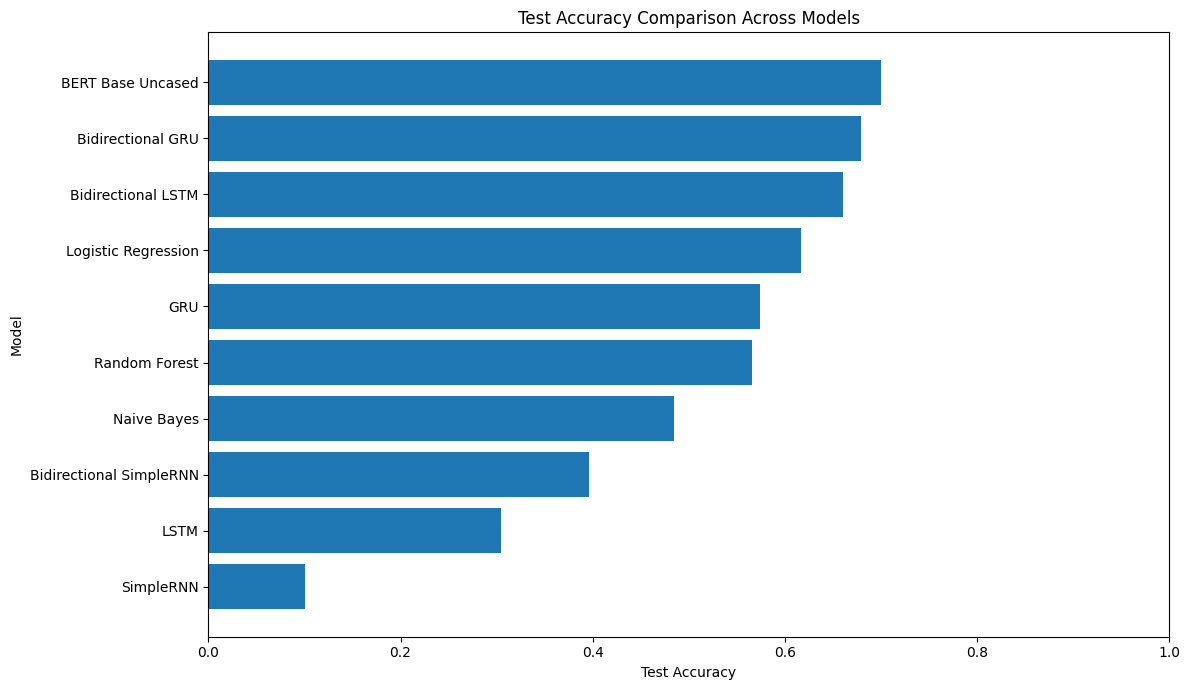

In [84]:
# ============================================================
# TEST ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

plot_data = df_test_results.sort_values(
    'Test Accuracy',
    ascending=True
)

plt.barh(
    plot_data['Model'],
    plot_data['Test Accuracy']
)

plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.title("Test Accuracy Comparison Across Models")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

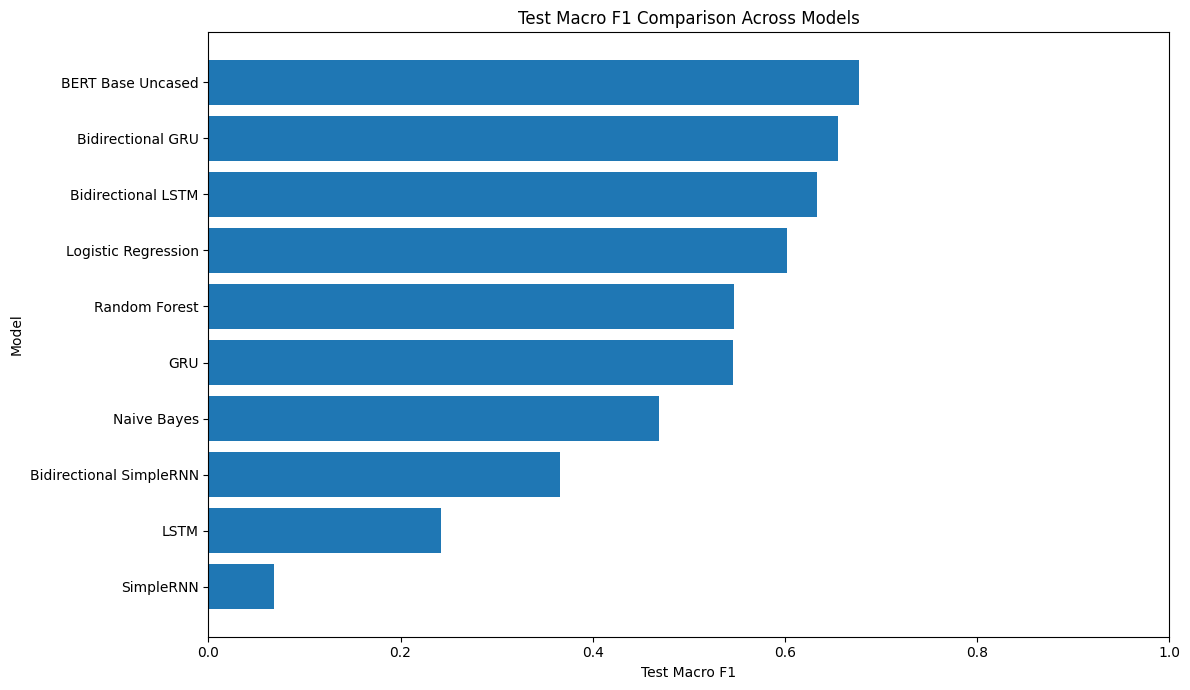

In [85]:
# ============================================================
# TEST MACRO F1 COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

plot_data = df_test_results.sort_values(
    'Test Macro F1',
    ascending=True
)

plt.barh(
    plot_data['Model'],
    plot_data['Test Macro F1']
)

plt.xlabel("Test Macro F1")
plt.ylabel("Model")
plt.title("Test Macro F1 Comparison Across Models")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [86]:
# ============================================================
# FULL CLASSIFICATION REPORTS
# ============================================================

for model_name, predictions in test_predictions.items():

    print("\n")
    print("=" * 100)
    print(f"CLASSIFICATION REPORT: {model_name}")
    print("=" * 100)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=target_names,
            digits=4
        )
    )



CLASSIFICATION REPORT: BERT Base Uncased
                          precision    recall  f1-score   support

             alt.atheism     0.4911    0.4825    0.4867       114
           comp.graphics     0.5562    0.7071    0.6226       140
 comp.os.ms-windows.misc     0.6036    0.7338    0.6623       139
comp.sys.ibm.pc.hardware     0.5734    0.5734    0.5734       143
   comp.sys.mac.hardware     0.7000    0.6131    0.6537       137
          comp.windows.x     0.8167    0.6901    0.7481       142
            misc.forsale     0.8250    0.7174    0.7674       138
               rec.autos     0.8387    0.7704    0.8031       135
         rec.motorcycles     0.7388    0.7071    0.7226       140
      rec.sport.baseball     0.7469    0.8768    0.8067       138
        rec.sport.hockey     0.8367    0.8601    0.8483       143
               sci.crypt     0.7970    0.7571    0.7766       140
         sci.electronics     0.6903    0.5571    0.6166       140
                 sci.med     0.8

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

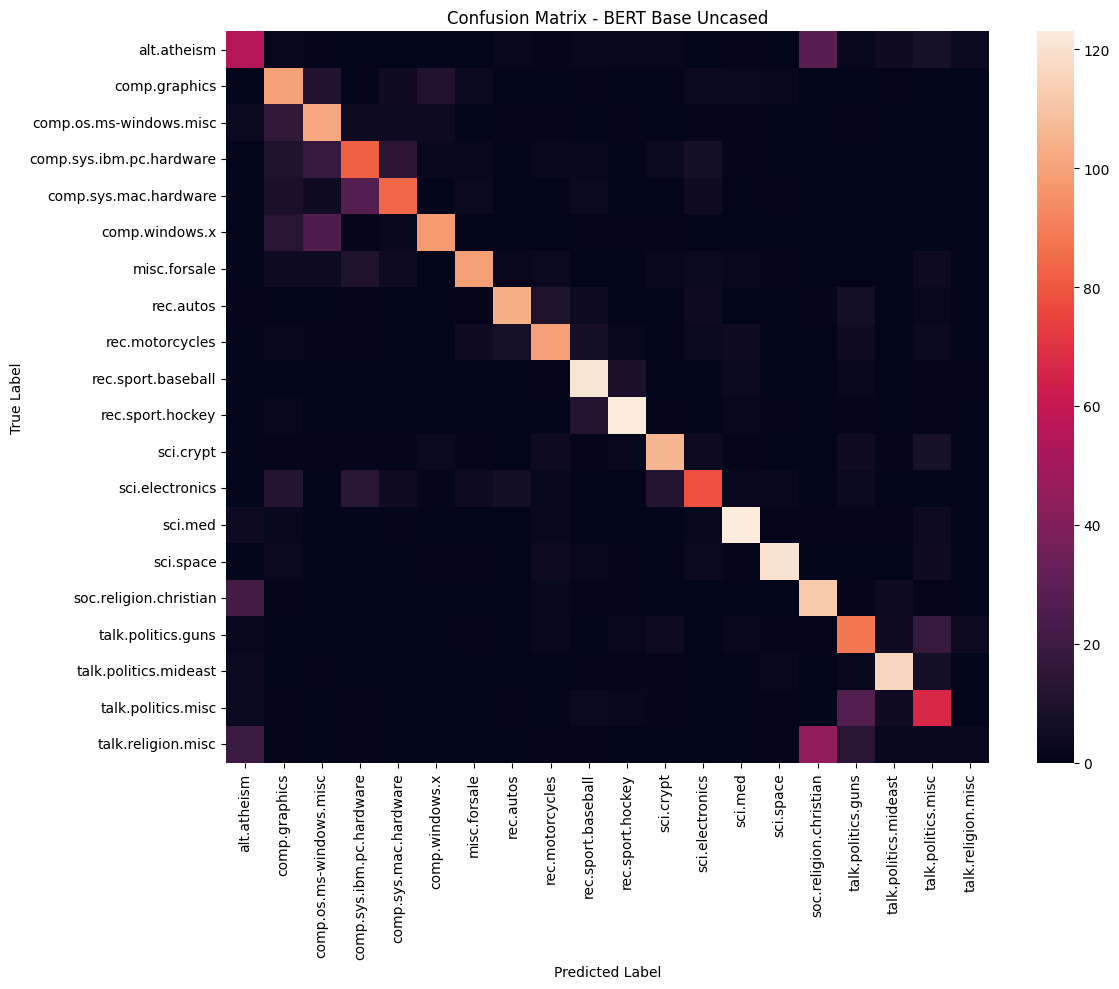

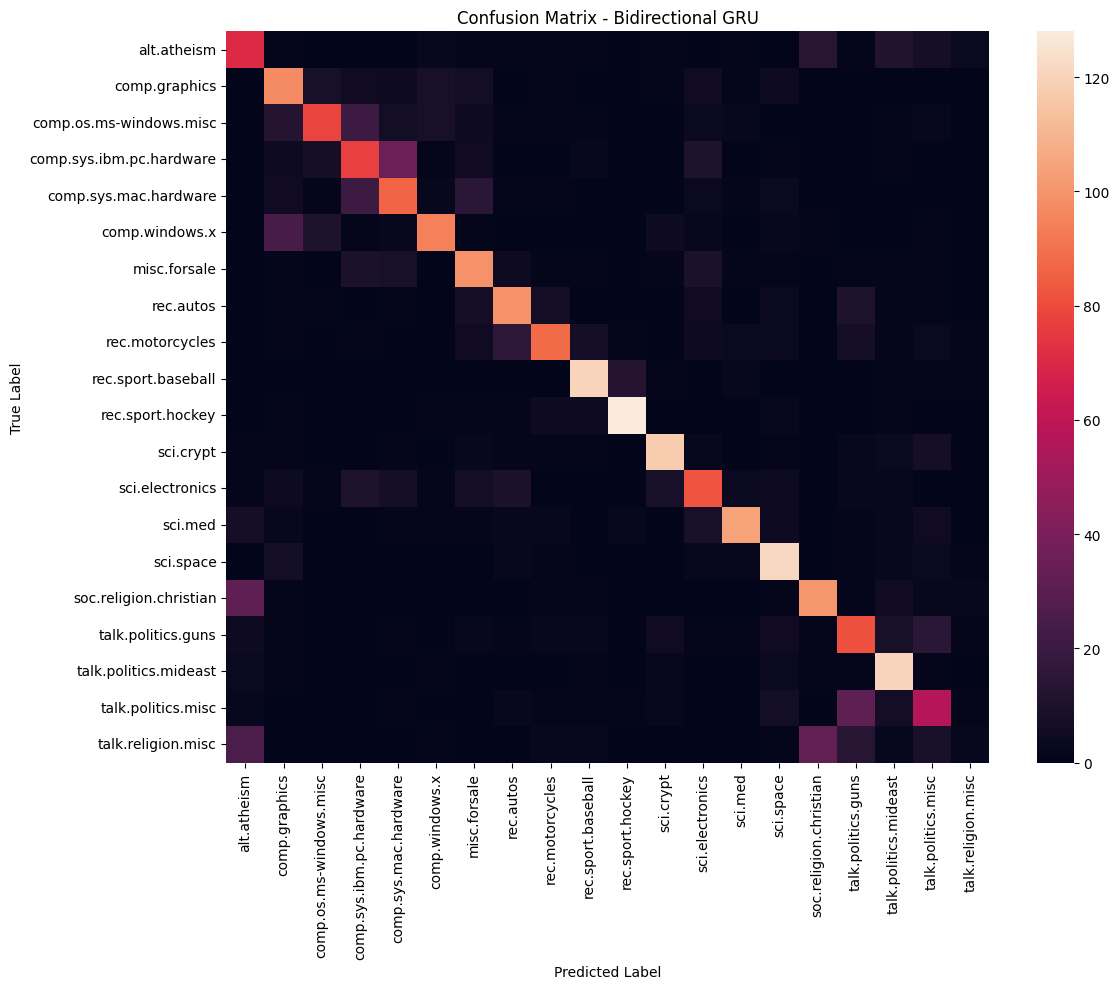

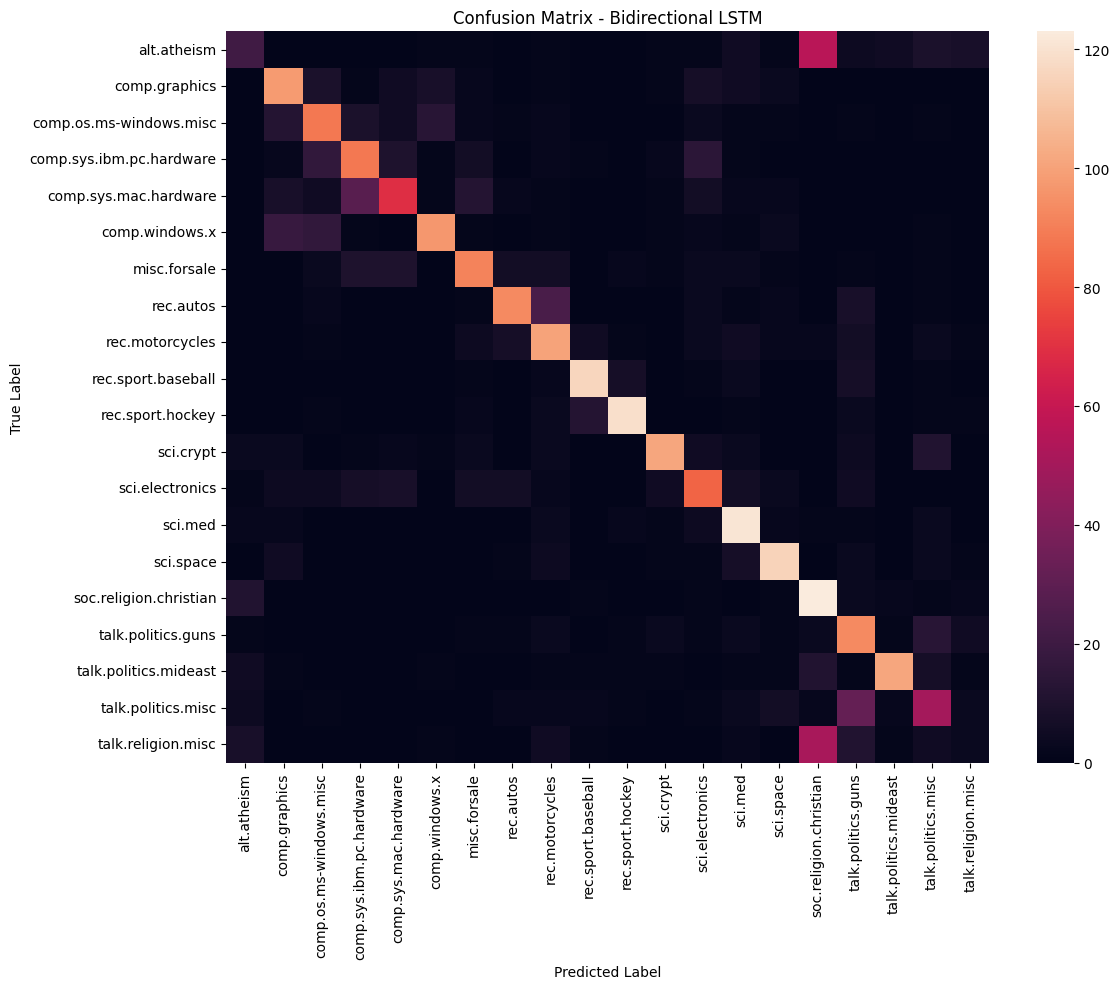

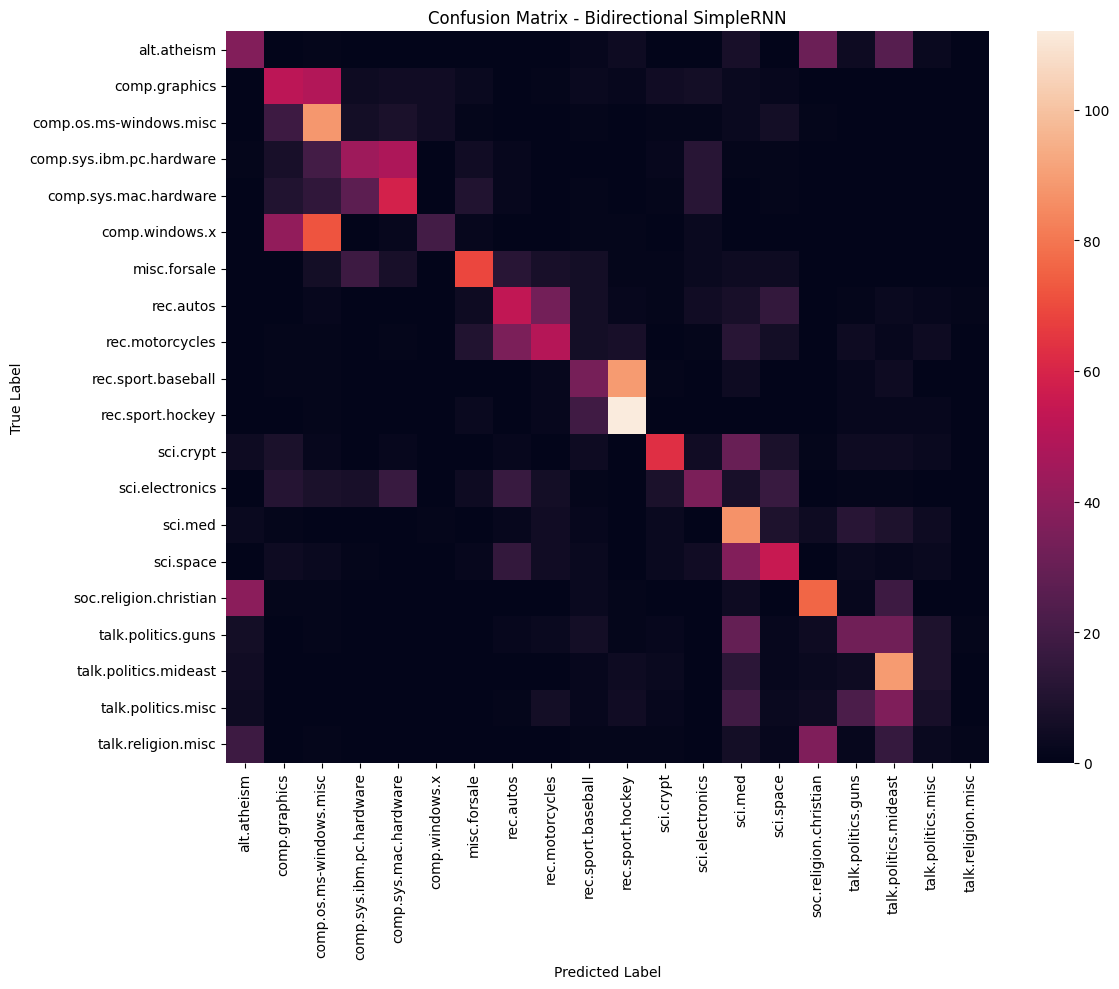

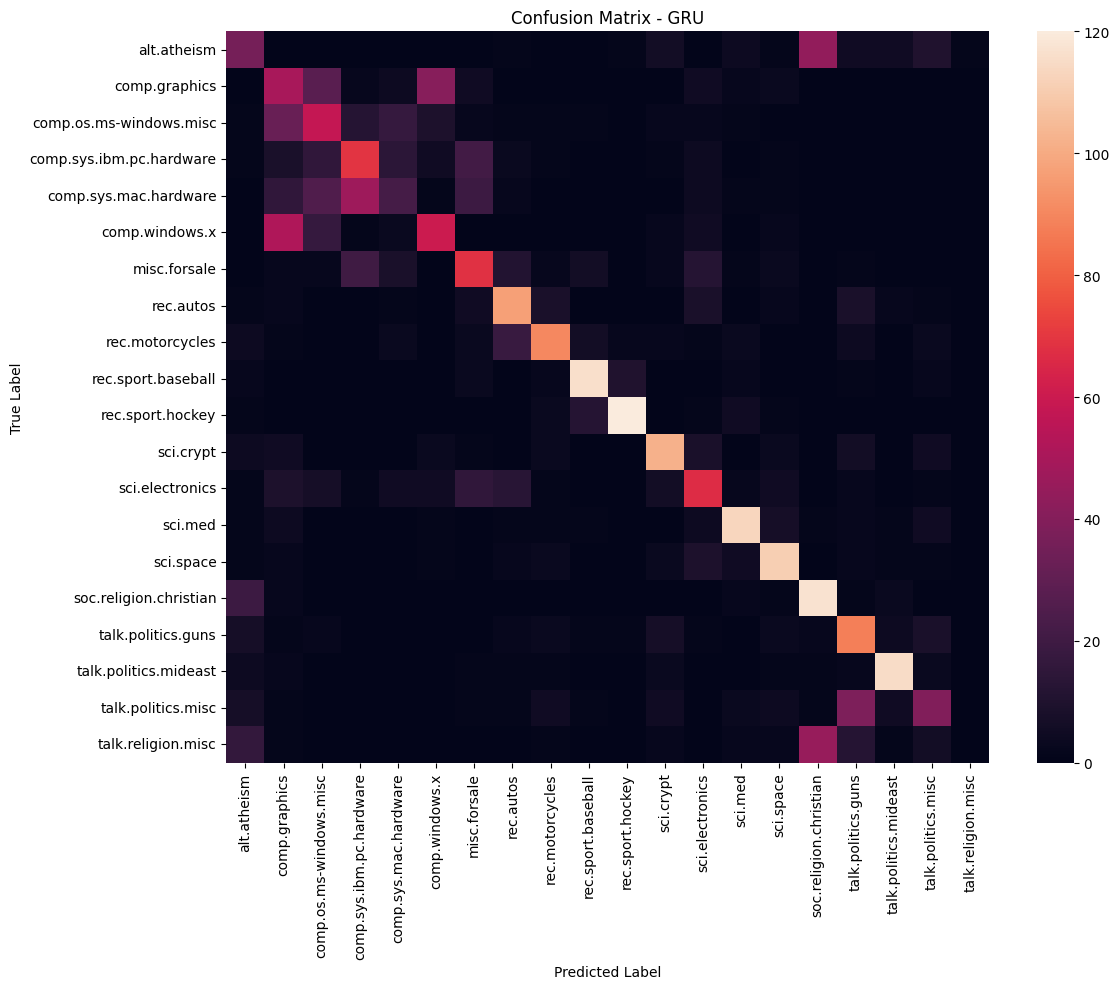

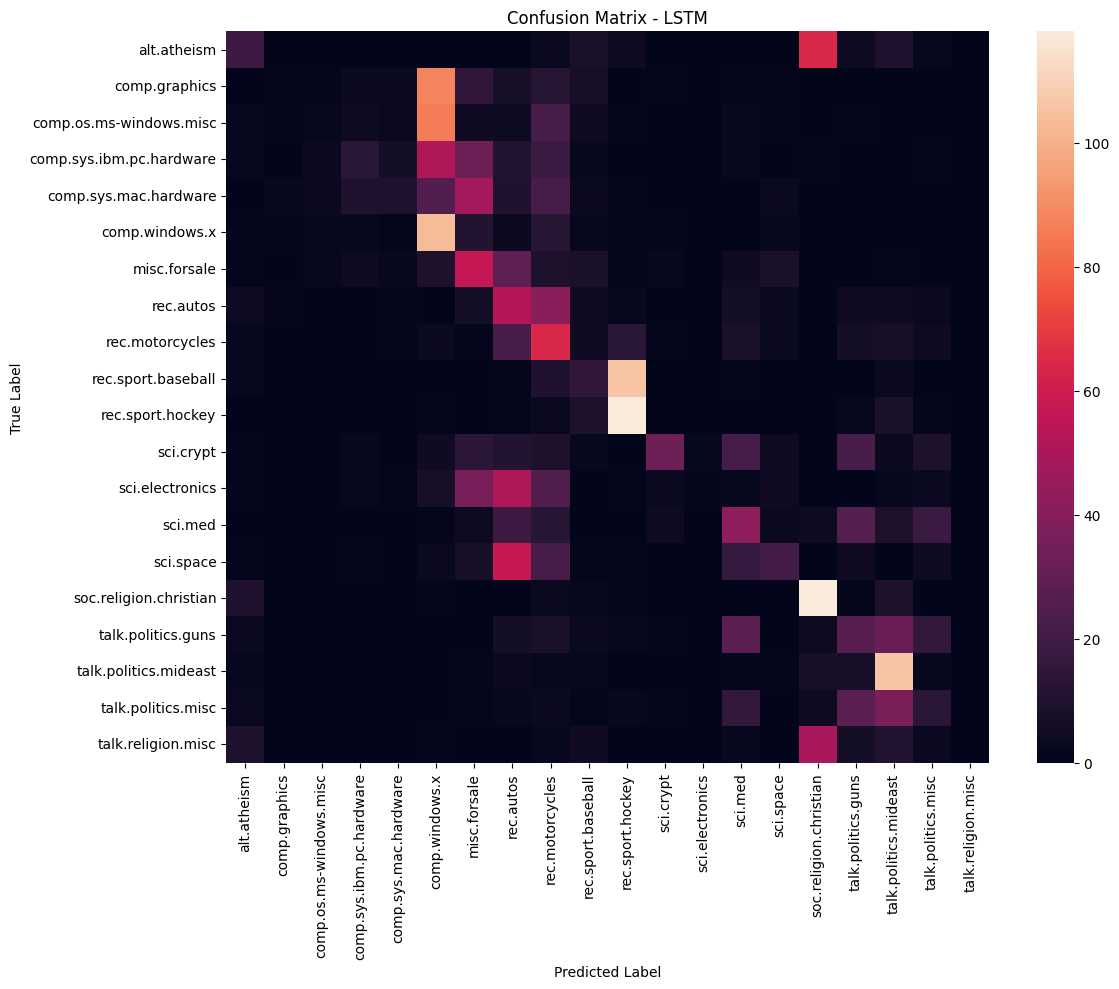

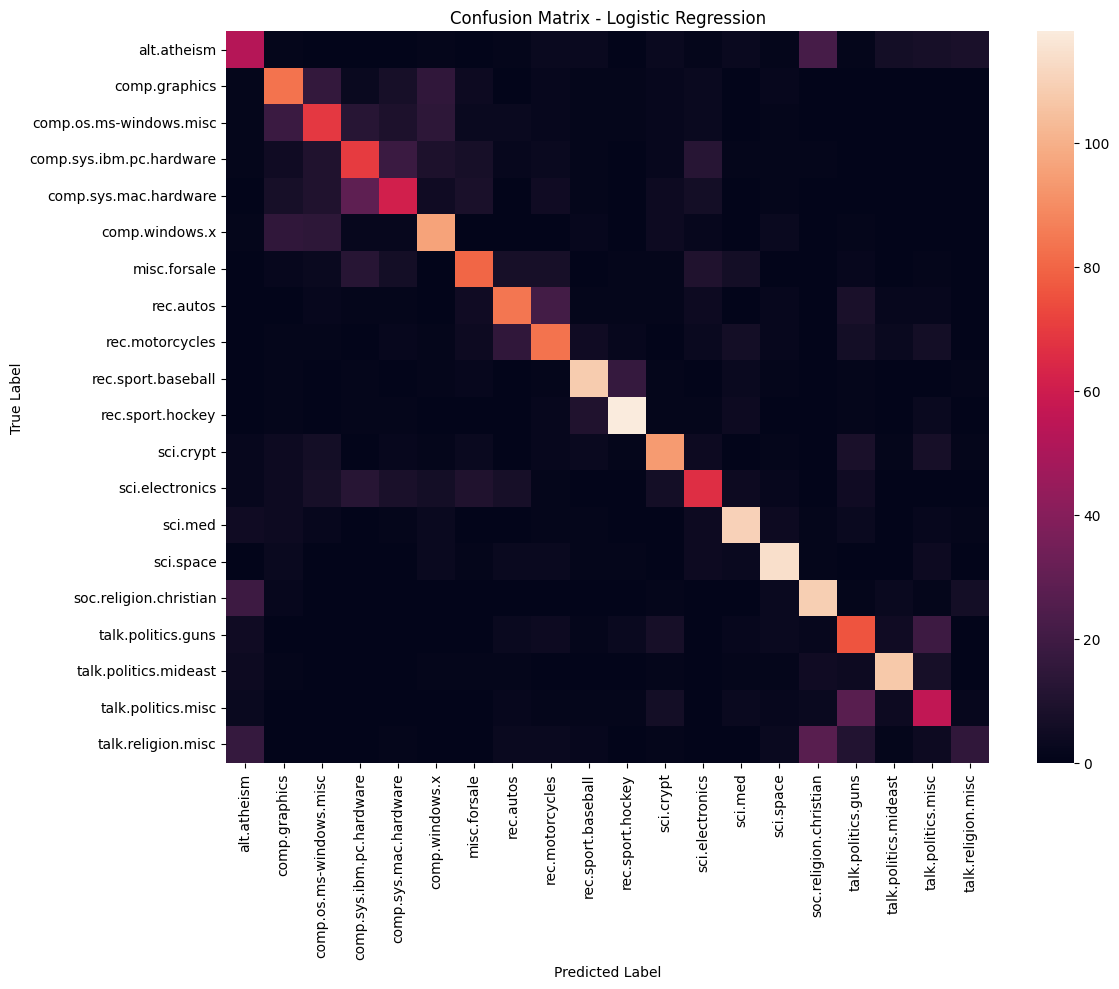

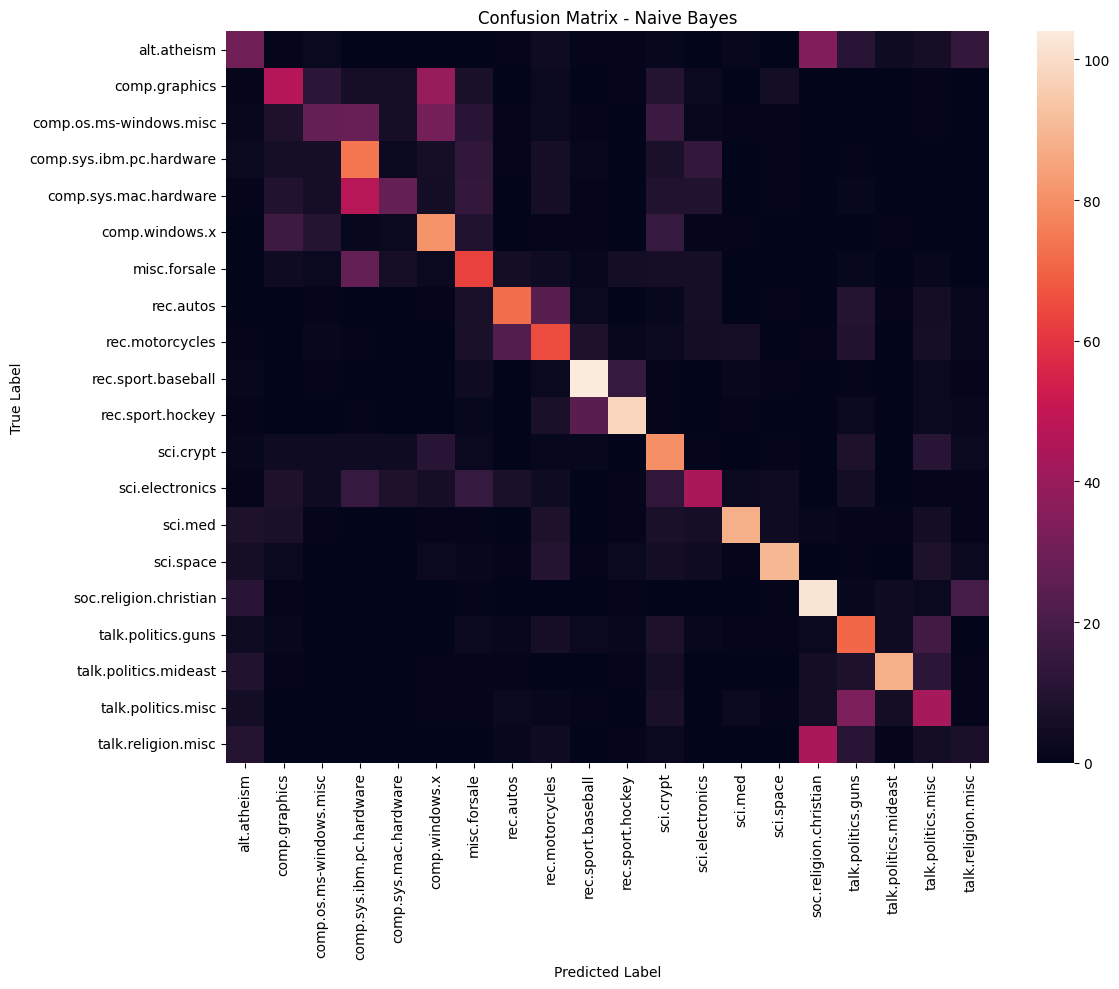

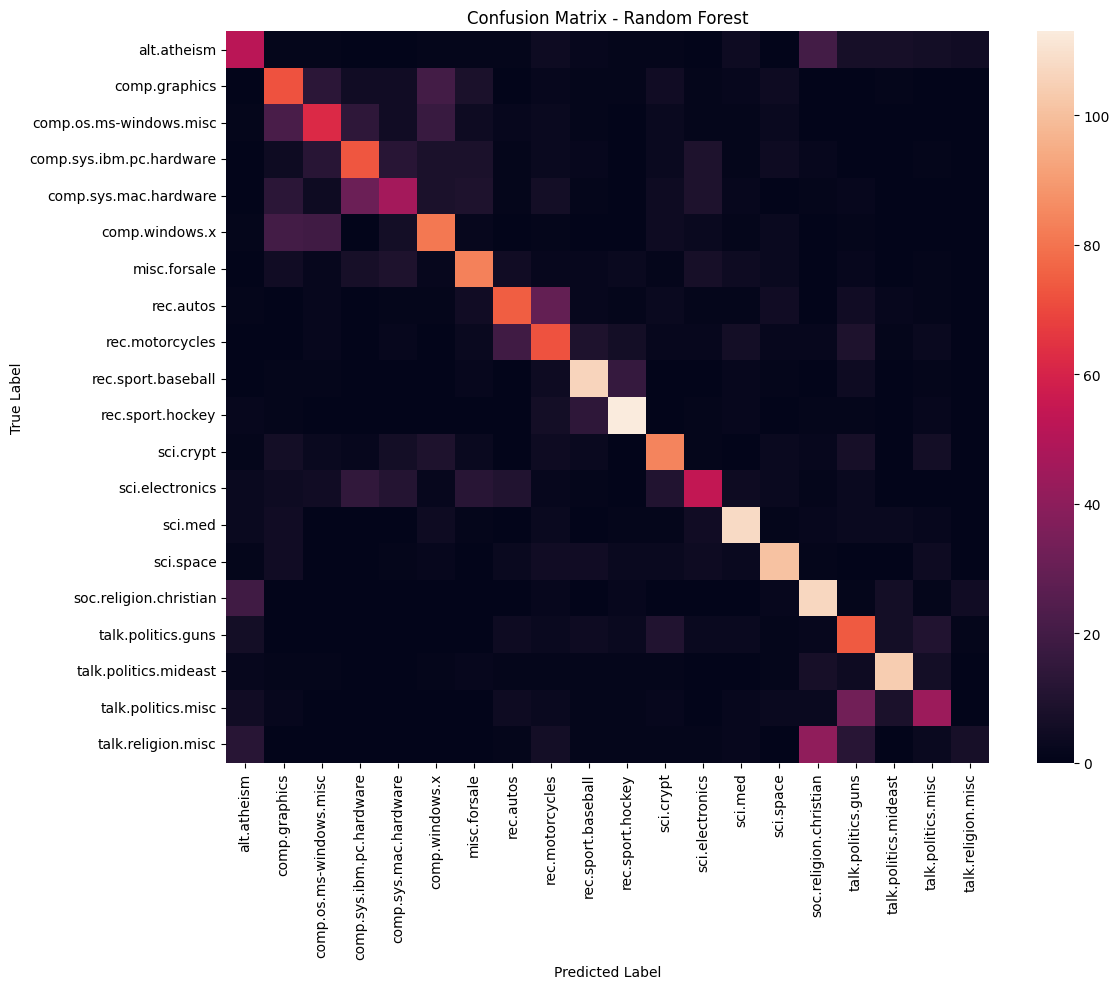

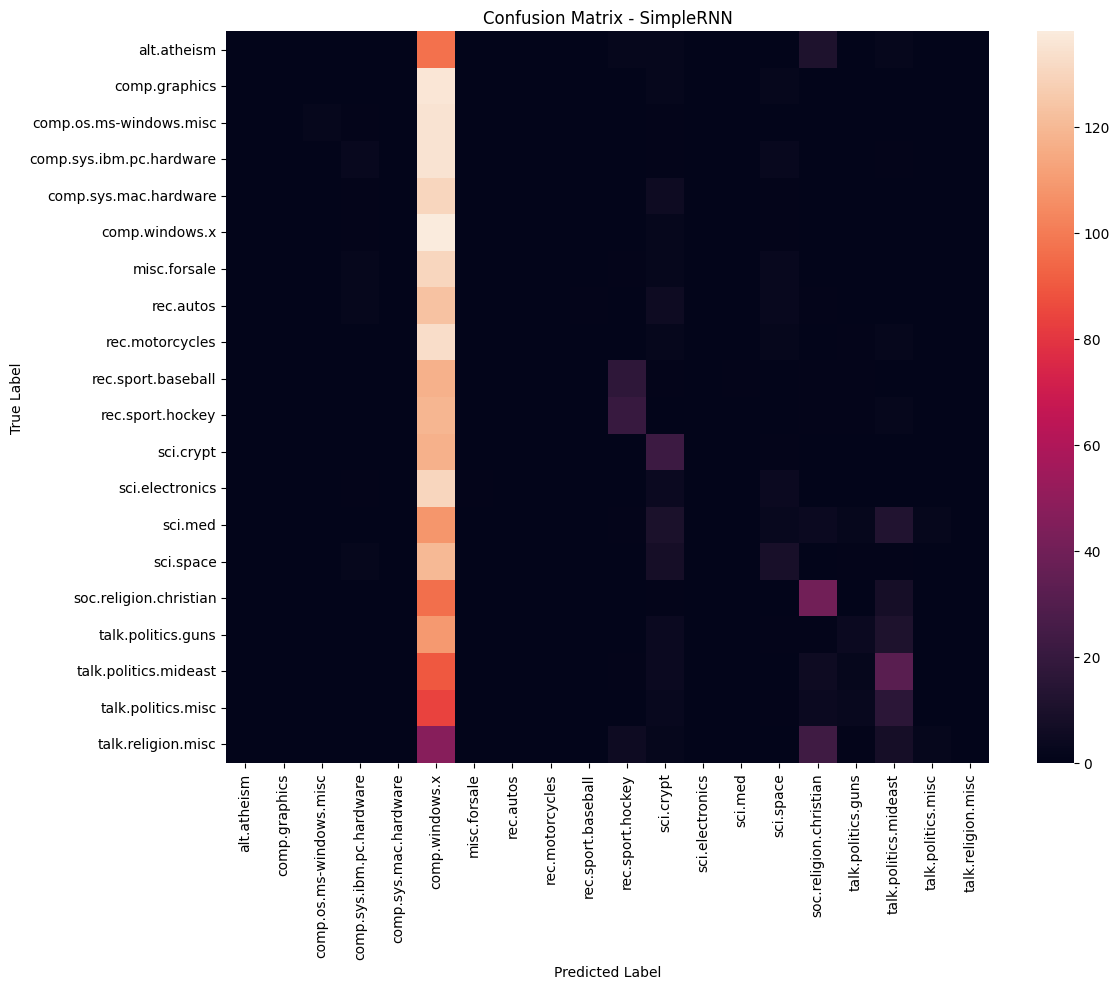

In [87]:
# ============================================================
# CONFUSION MATRICES FOR ALL MODELS
# ============================================================

for model_name, predictions in test_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        cm,
        annot=False,
        fmt='d',
        xticklabels=target_names,
        yticklabels=target_names
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [88]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

final_comparison = df_test_results[
    [
        'Model',
        'Embedding',
        'Config',
        'Val Accuracy',
        'Val Macro F1',
        'Test Accuracy',
        'Test Macro F1'
    ]
].copy()

final_comparison = final_comparison.sort_values(
    'Test Macro F1',
    ascending=False
).reset_index(drop=True)

print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

display(final_comparison)

FINAL MODEL COMPARISON


,Model,Embedding,Config,Val Accuracy,Val Macro F1,Test Accuracy,Test Macro F1
0,BERT Base Uncased,N/A,Config_3,0.7115,0.6874,0.7007,0.6773
1,Bidirectional GRU,GloVe,Config_2,0.6782,0.6584,0.6791,0.6557
2,Bidirectional LSTM,GloVe,Config_1,0.6495,0.6247,0.6604,0.6340
3,Logistic Regression,GloVe,Config_2,0.6069,0.5888,0.6164,0.6019
4,Random Forest,GloVe,Config_3,0.5782,0.5565,0.5664,0.5471
5,GRU,GloVe,Config_1,0.5666,0.5414,0.5739,0.5461
6,Naive Bayes,GloVe,Config_1,0.4860,0.4715,0.4851,0.4695
7,Bidirectional SimpleRNN,Word2Vec,Config_1,0.3927,0.3647,0.3966,0.3660
8,LSTM,Word2Vec,Config_1,0.3038,0.2412,0.3045,0.2419
9,SimpleRNN,Word2Vec,Config_2,0.1004,0.0674,0.1007,0.0683


Bonus

In [89]:
# ============================================================
# BONUS 1: ENSEMBLE
# Select the best models using validation Macro F1
# ============================================================

print("=" * 80)
print("BONUS: TOP MODELS FOR ENSEMBLE")
print("=" * 80)

top_3_models = (
    best_configs
    .sort_values(
        'Val Macro F1',
        ascending=False
    )
    .head(3)
)

display(
    top_3_models[
        [
            'Family',
            'Model Name',
            'Embedding',
            'Config ID',
            'Val Accuracy',
            'Val Macro F1'
        ]
    ]
)

BONUS: TOP MODELS FOR ENSEMBLE


,Family,Model Name,Embedding,Config ID,Val Accuracy,Val Macro F1
0,Transformer,BERT Base Uncased,N/A,Config_3,0.7115,0.6874
1,Recurrent NN,Bidirectional GRU,GloVe,Config_2,0.6782,0.6584
2,Recurrent NN,Bidirectional LSTM,GloVe,Config_1,0.6495,0.6247


In [90]:
# ============================================================
# BONUS: MAJORITY VOTING ENSEMBLE
# ============================================================

from scipy.stats import mode

selected_model_names = (
    top_3_models['Model Name']
    .tolist()
)

print("Models included in ensemble:")
for model_name in selected_model_names:
    print("-", model_name)

# Collect predictions
ensemble_prediction_matrix = np.vstack([
    test_predictions[name]
    for name in selected_model_names
])

# Majority voting
ensemble_predictions = mode(
    ensemble_prediction_matrix,
    axis=0,
    keepdims=False
).mode

ensemble_predictions = np.asarray(
    ensemble_predictions
).astype(int)

print(
    f"\nEnsemble predictions generated for "
    f"{len(ensemble_predictions):,} test samples."
)

Models included in ensemble:
- BERT Base Uncased
- Bidirectional GRU
- Bidirectional LSTM

Ensemble predictions generated for 2,680 test samples.


In [91]:
# ============================================================
# BONUS: ENSEMBLE TEST EVALUATION
# ============================================================

ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_predictions
)

ensemble_f1 = f1_score(
    y_test,
    ensemble_predictions,
    average='macro'
)

print("=" * 80)
print("ENSEMBLE TEST RESULTS")
print("=" * 80)

print(
    f"Ensemble Test Accuracy: "
    f"{ensemble_accuracy:.4f}"
)

print(
    f"Ensemble Test Macro F1: "
    f"{ensemble_f1:.4f}"
)

ENSEMBLE TEST RESULTS
Ensemble Test Accuracy: 0.7104
Ensemble Test Macro F1: 0.6848


In [92]:
# ============================================================
# BONUS: ENSEMBLE VS INDIVIDUAL MODELS
# ============================================================

ensemble_comparison = df_test_results[
    df_test_results['Model'].isin(
        selected_model_names
    )
][
    [
        'Model',
        'Test Accuracy',
        'Test Macro F1'
    ]
].copy()

ensemble_row = pd.DataFrame({
    'Model': ['Ensemble'],
    'Test Accuracy': [ensemble_accuracy],
    'Test Macro F1': [ensemble_f1]
})

ensemble_comparison = pd.concat(
    [
        ensemble_comparison,
        ensemble_row
    ],
    ignore_index=True
)

display(
    ensemble_comparison.sort_values(
        'Test Macro F1',
        ascending=False
    )
)

,Model,Test Accuracy,Test Macro F1
3,Ensemble,0.710448,0.684823
0,BERT Base Uncased,0.700700,0.677300
1,Bidirectional GRU,0.679100,0.655700
2,Bidirectional LSTM,0.660400,0.634000


In [93]:
# ============================================================
# BONUS: IMPROVEMENT ANALYSIS
# ============================================================

best_individual_f1 = (
    df_test_results[
        df_test_results['Model'].isin(
            selected_model_names
        )
    ]['Test Macro F1']
    .max()
)

best_individual_accuracy = (
    df_test_results[
        df_test_results['Model'].isin(
            selected_model_names
        )]['Test Accuracy']
    .max()
)

f1_improvement = (
    ensemble_f1 - best_individual_f1
)

accuracy_improvement = (
    ensemble_accuracy - best_individual_accuracy
)

print("=" * 80)
print("ENSEMBLE IMPROVEMENT")
print("=" * 80)

print(
    f"Best individual Test Macro F1: "
    f"{best_individual_f1:.4f}"
)

print(
    f"Ensemble Test Macro F1: "
    f"{ensemble_f1:.4f}"
)

print(
    f"Macro F1 improvement: "
    f"{f1_improvement:+.4f}"
)

print()

print(
    f"Best individual Test Accuracy: "
    f"{best_individual_accuracy:.4f}"
)

print(
    f"Ensemble Test Accuracy: "
    f"{ensemble_accuracy:.4f}"
)

print(
    f"Accuracy improvement: "
    f"{accuracy_improvement:+.4f}"
)

if f1_improvement > 0:
    print("\n✓ Ensemble improved Macro F1.")
else:
    print("\n✗ Ensemble did not improve Macro F1.")

ENSEMBLE IMPROVEMENT
Best individual Test Macro F1: 0.6773
Ensemble Test Macro F1: 0.6848
Macro F1 improvement: +0.0075

Best individual Test Accuracy: 0.7007
Ensemble Test Accuracy: 0.7104
Accuracy improvement: +0.0097

✓ Ensemble improved Macro F1.


In [94]:
# ============================================================
# BONUS: COMPARE 2-MODEL AND 3-MODEL ENSEMBLES
# ============================================================

from itertools import combinations

ensemble_results = []

candidate_models = (
    best_configs
    .sort_values(
        'Val Macro F1',
        ascending=False
    )
    ['Model Name']
    .tolist()
)

# Use top 4 models as candidates
candidate_models = candidate_models[:4]

for ensemble_size in [2, 3]:

    for combination in combinations(
        candidate_models,
        ensemble_size
    ):

        prediction_matrix = np.vstack([
            test_predictions[name]
            for name in combination
        ])

        predictions = mode(
            prediction_matrix,
            axis=0,
            keepdims=False
        ).mode

        predictions = np.asarray(
            predictions
        ).astype(int)

        acc = accuracy_score(
            y_test,
            predictions
        )

        f1 = f1_score(
            y_test,
            predictions,
            average='macro'
        )

        ensemble_results.append({

            'Models': " + ".join(combination),

            'Number of Models': ensemble_size,

            'Test Accuracy': acc,

            'Test Macro F1': f1
        })


ensemble_results_df = pd.DataFrame(
    ensemble_results
)

ensemble_results_df = (
    ensemble_results_df
    .sort_values(
        'Test Macro F1',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ensemble_results_df
)

,Models,Number of Models,Test Accuracy,Test Macro F1
0,BERT Base Uncased + Bidirectional GRU + Bidire...,3,0.710448,0.684823
1,BERT Base Uncased + Bidirectional GRU + Logist...,3,0.701119,0.678058
2,BERT Base Uncased + Bidirectional GRU,2,0.693657,0.668525
3,BERT Base Uncased + Bidirectional LSTM + Logis...,3,0.691791,0.667948
4,BERT Base Uncased + Bidirectional LSTM,2,0.681343,0.655166
5,Bidirectional GRU + Bidirectional LSTM + Logis...,3,0.677612,0.653701
6,Bidirectional GRU + Bidirectional LSTM,2,0.674254,0.648728
7,BERT Base Uncased + Logistic Regression,2,0.656716,0.634373
8,Bidirectional GRU + Logistic Regression,2,0.645896,0.622570
9,Bidirectional LSTM + Logistic Regression,2,0.641045,0.616280


In [95]:
# ============================================================
# BEST ENSEMBLE
# ============================================================

best_ensemble = (
    ensemble_results_df
    .iloc[0]
)

print("=" * 80)
print("BEST ENSEMBLE")
print("=" * 80)

print(
    f"Models: {best_ensemble['Models']}"
)

print(
    f"Number of models: "
    f"{best_ensemble['Number of Models']}"
)

print(
    f"Test Accuracy: "
    f"{best_ensemble['Test Accuracy']:.4f}"
)

print(
    f"Test Macro F1: "
    f"{best_ensemble['Test Macro F1']:.4f}"
)

BEST ENSEMBLE
Models: BERT Base Uncased + Bidirectional GRU + Bidirectional LSTM
Number of models: 3
Test Accuracy: 0.7104
Test Macro F1: 0.6848


# Bonus 2: Ablation Study

We compare two preprocessing strategies using the same Logistic Regression model and GloVe representation:

1. Basic cleaning only
2. Full preprocessing with stopword removal and lemmatization

This allows us to measure the contribution of the additional preprocessing steps.

In [96]:
# ============================================================
# BONUS 2: ABLATION STUDY
# ============================================================

print("=" * 60)
print("BONUS 2: ABLATION STUDY")
print("=" * 60)

# Create GloVe vectors using BASIC cleaning
basic_train_tokens = [text.split() for text in train_df['basic_text']]
basic_test_tokens = [text.split() for text in test_df['basic_text']]

X_basic_train = build_doc_matrix(
    basic_train_tokens,
    glove_vectors
)

X_basic_test = build_doc_matrix(
    basic_test_tokens,
    glove_vectors
)

# Logistic Regression - Basic Cleaning
model_basic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_basic.fit(X_basic_train, y_train)

pred_basic = model_basic.predict(X_basic_test)

basic_accuracy = accuracy_score(
    y_test,
    pred_basic
)

basic_f1 = f1_score(
    y_test,
    pred_basic,
    average='macro'
)

# ------------------------------------------------------------
# Full preprocessing
# ------------------------------------------------------------

model_full = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_full.fit(X_train_glove, y_train)

pred_full = model_full.predict(X_test_glove)

full_accuracy = accuracy_score(
    y_test,
    pred_full
)

full_f1 = f1_score(
    y_test,
    pred_full,
    average='macro'
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

ablation_results = pd.DataFrame({
    "Preprocessing": [
        "Basic Cleaning",
        "Full Preprocessing"
    ],
    "Accuracy": [
        basic_accuracy,
        full_accuracy
    ],
    "Macro F1": [
        basic_f1,
        full_f1
    ]
})

display(ablation_results)

print("\nImprovement:")
print(
    f"Accuracy: {(full_accuracy - basic_accuracy) * 100:+.2f} percentage points"
)

print(
    f"Macro F1: {(full_f1 - basic_f1) * 100:+.2f} percentage points"
)

BONUS 2: ABLATION STUDY


,Preprocessing,Accuracy,Macro F1
0,Basic Cleaning,0.616418,0.597455
1,Full Preprocessing,0.616418,0.601897



Improvement:
Accuracy: +0.00 percentage points
Macro F1: +0.44 percentage points
